<a href="https://colab.research.google.com/github/SUHANI-21/MachineLearningLab-2/blob/main/BaggingBoosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# BAGGING AND BOOSTING CLASSIFICATION
# Dataset: Iris
# ============================================

# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
# ============================================
# 2. Load the supervised dataset
# ============================================

iris = load_iris(as_frame=True)

X = iris.data
y = iris.target

print("Dataset Shape:", X.shape)
print("\nFeature Names:")
print(X.columns.tolist())

print("\nTarget Classes:")
print(iris.target_names)

print("\nFirst 5 rows:")
print(X.head())


Dataset Shape: (150, 4)

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Classes:
['setosa' 'versicolor' 'virginica']

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [ ]:
# ============================================
# 3. Split dataset into training and testing
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 120
Testing samples: 30


In [ ]:
# ============================================
# 4. Create Bagging and Boosting models
# ============================================

models = {

    # Bagging
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100,
        random_state=42
    ),

    # Random Forest - bagging of decision trees
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    # Boosting
    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    ),

    # Gradient Boosting
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    )
}


In [ ]:
# ============================================
# 5. Train and evaluate models
# ============================================

results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test, y_pred, average="weighted"
    )
    recall = recall_score(
        y_test, y_pred, average="weighted"
    )
    f1 = f1_score(
        y_test, y_pred, average="weighted"
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("\nAccuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-Score:", f1)

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=iris.target_names
        )
    )



Bagging

Accuracy: 0.9666666666666667
Precision: 0.9696969696969696
Recall: 0.9666666666666667
F1-Score: 0.9665831244778613

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Random Forest

Accuracy: 0.9
Precision: 0.9023569023569024
Recall: 0.9
F1-Score: 0.8997493734335839

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       

In [ ]:
# ============================================
# 6. Performance comparison
# ============================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

print("\n\nPERFORMANCE COMPARISON")
print("=" * 70)

print(
    results_df.to_string(
        index=False,
        formatters={
            "Accuracy": "{:.4f}".format,
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1-Score": "{:.4f}".format
        }
    )
)



PERFORMANCE COMPARISON
            Model Accuracy Precision Recall F1-Score
          Bagging   0.9667    0.9697 0.9667   0.9666
    Random Forest   0.9000    0.9024 0.9000   0.8997
         AdaBoost   0.9333    0.9333 0.9333   0.9333
Gradient Boosting   0.9667    0.9697 0.9667   0.9666


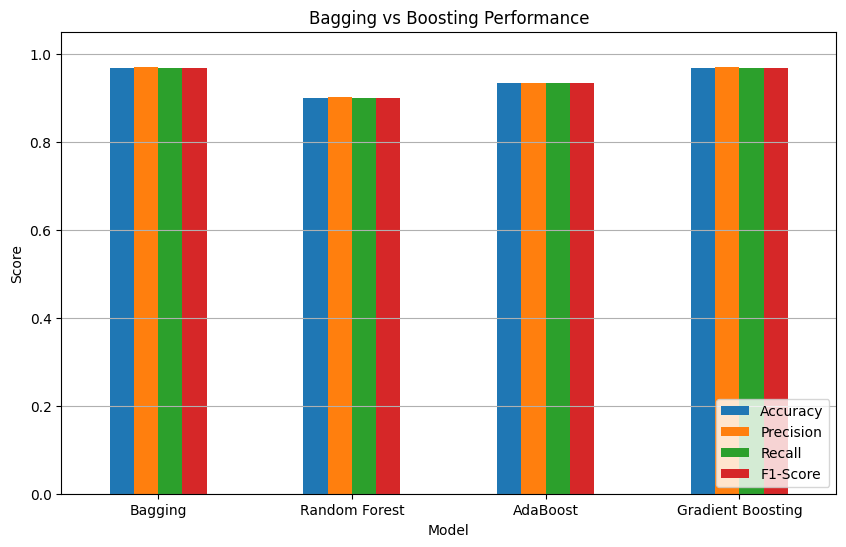

In [ ]:
# ============================================
# 7. Plot comparison
# ============================================

results_plot = results_df.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Bagging vs Boosting Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y")
plt.show()


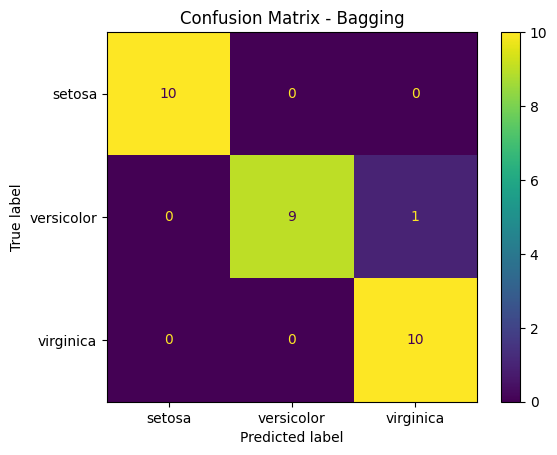

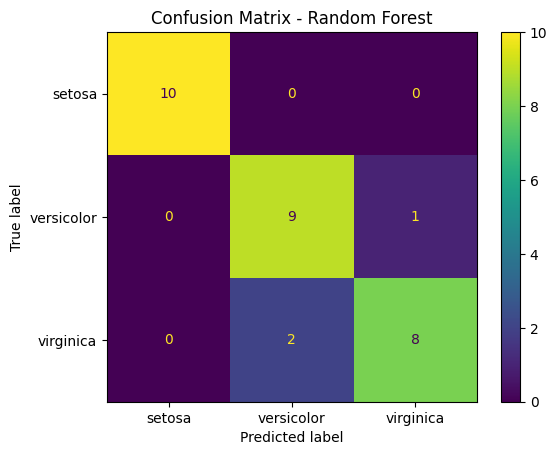

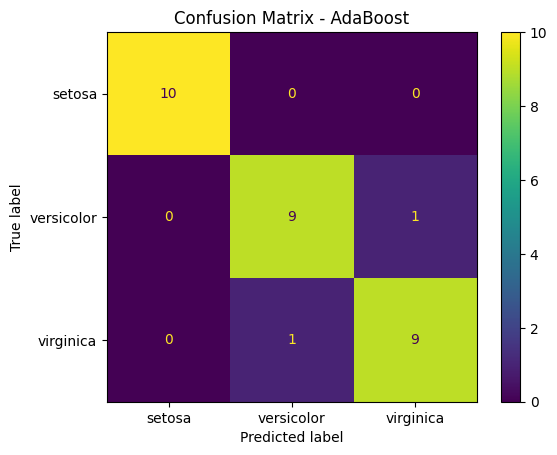

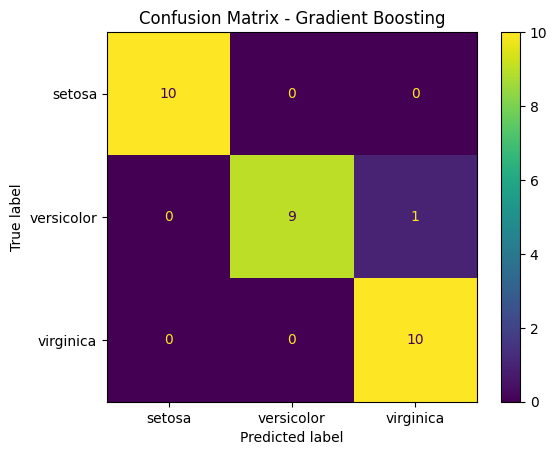

In [ ]:
# ============================================
# 8. Confusion matrices
# ============================================

for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=iris.target_names
    )

    disp.plot()

    plt.title(f"Confusion Matrix - {name}")
    plt.show()